# Feature importance + POD curves (paper revision)

Updated for the new 100 m training runs. Reads permutation-importance
CSVs from:

- **U.S.**:  `data/us/Run_100m_20260414/training_no_stats_item/feature_importance/feature_importance_permutation_all_data_filtered_yearly.csv`
- **World**: `data/world/pipeline_test_labelling_100m/Run_100m_20260428/training_no_stats_item/feature_importance/feature_importance_permutation_all_data_filtered.csv`

and replots the combined feature-importance ranking + POD-vs-feature curves
(top-3 features + wind speed) for both U.S. and Global.

In [1]:
import os, sys, numpy as np, pandas as pd
from pathlib import Path
from functools import reduce
from math import radians, log10
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

sys.path.insert(0, '/net/fs06/d3/rzhuang/TROPOMI/code')
from shared.interference import (identify_interference_us_by_year,
                                 identify_interference_world,
                                 extract_year_from_datetime)

plt.rcdefaults()
sns.set_palette('husl')
plt.rcParams.update({
    'figure.dpi': 300, 'savefig.dpi': 300,
    'font.size': 10,
    'axes.linewidth': 0.8, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#2E3440', 'axes.labelcolor': '#2E3440', 'text.color': '#2E3440',
    'xtick.color': '#2E3440', 'ytick.color': '#2E3440',
    'grid.alpha': 0.3, 'grid.linewidth': 0.5,
})

# Register Nimbus Roman with matplotlib's font manager so we can refer to it
# by name in rcParams.
nimbus_path = None
for _p in fm.findSystemFonts():
    _pl = _p.lower()
    if ('nimbusroman' in _pl or 'nimbus_roman' in _pl) \
            and 'bold' not in _pl and 'italic' not in _pl and 'oblique' not in _pl:
        nimbus_path = _p; break
if nimbus_path:
    fm.fontManager.addfont(nimbus_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=nimbus_path).get_name()
    print('Registered:', plt.rcParams['font.family'], '->', nimbus_path)
else:
    print('Nimbus Roman not found; using matplotlib default')

colors = {'us': '#FF6B6B', 'global': '#4ECDC4', 'text': '#2E3440'}


Registered: ['Nimbus Roman'] -> /usr/share/fonts/urw-base35/NimbusRoman-Regular.otf


In [2]:
# ─── Paths (paper revision: new 100 m training output) ───────────────
FILES = {
    'US':     Path('/net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/training_no_stats_item/feature_importance/feature_importance_permutation_all_data_filtered_yearly.csv'),
    'Global': Path('/net/fs06/d3/rzhuang/TROPOMI/data/world/pipeline_test_labelling_100m/Run_100m_20260428/training_no_stats_item/feature_importance/feature_importance_permutation_all_data_filtered.csv'),
}
OBS_FILES = {
    'US':     Path('/net/fs06/d3/rzhuang/TROPOMI/pipeline_100m_run/Run_100m_20260414/updated_tropomi_hourly_emissions_full_variables_augmented_localtz.csv'),
    'Global': Path('/net/fs06/d3/rzhuang/TROPOMI/data/world/pipeline_test_labelling_100m/Run_100m_20260428/updated_tropomi_emissions_full_variables_with_fuel_100mlabel.csv'),
}
PATHS = {
    'US_PLANTS':      Path('/net/fs06/d3/rzhuang/TROPOMI/data/us/facility_emissions_by_plant_comprehensive.csv'),
    'US_ANNUAL_EMIS': Path('/net/fs06/d3/rzhuang/TROPOMI/data/us/annual-emissions-facility-aggregation-2019-2024.csv'),
    'GLOBAL_PLANTS':  Path('/net/fs06/d3/rzhuang/TROPOMI/data/world/power_plant_location/power_plants_with_combined_nearby_stats.csv'),
    'CITIES':         Path('/net/fs06/d3/rzhuang/TROPOMI/data/world/worldcities.csv'),
}
OUT_DIR = '/net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/paper_figures'
os.makedirs(OUT_DIR, exist_ok=True)

BINS, MIN_COUNT = 20, 10
BIN_STRATEGY = 'quantile'
CLIP_QUANTILES = (0.01, 0.99)
CLIP_METHOD = 'drop'
X_PAD_FRAC = 0.03
Y_SCALE_MODE, Y_SCALE_Q, Y_PAD = 'auto', (0.0, 1.0), 0.03
LBS_TO_KG = 0.45359237

TARGET_CANDIDATES = ['plume_label', 'label', 'detected', 'is_detected', 'target', 'y']
FEATURES_WITHOUT_NEARBY = [
    'annual_nox_emission','surface_altitude','surface_altitude_precision',
    'surface_classification','surface_pressure','surface_albedo',
    'surface_albedo_nitrogendioxide_window','cloud_pressure_crb',
    'cloud_fraction_crb','cloud_albedo_crb','scene_albedo',
    'apparent_scene_pressure','snow_ice_flag','aerosol_index_354_388',
    'scaled_small_pixel_variance','sensor_altitude','sensor_azimuth_angle',
    'sensor_zenith_angle','solar_azimuth_angle','solar_zenith_angle',
    'wind_speed','t2m','tisr','tcwv','primary_fuel_type','NOx Mass (lbs)',
]
EMISSION_CANON = 'Annual/Hourly NOx Emission'
EMISSION_KEYS = {EMISSION_CANON, 'NOx Mass (lbs)', 'annual_nox_emission', 'hourly_emission_rate'}

_feature_name_mapping = {
    'sensor_azimuth_angle': 'Sensor Azimuth Angle',
    'sensor_zenith_angle': 'Sensor Zenith Angle',
    'sensor_altitude': 'Sensor Altitude',
    'scaled_small_pixel_variance': 'Scaled Small-Pixel Variance',
    'annual_nox_emission': EMISSION_CANON,
    'NOx Mass (lbs)': EMISSION_CANON,
    'wind_speed': 'Wind Speed',
    'cloud_albedo_crb': 'Cloud Albedo CRB',
    'cloud_pressure_crb': 'Cloud Pressure CRB',
    'cloud_fraction_crb': 'Cloud Fraction CRB',
    'solar_zenith_angle': 'Solar Zenith Angle',
    'solar_azimuth_angle': 'Solar Azimuth Angle',
    'apparent_scene_pressure': 'Apparent Scene Pressure',
    'aerosol_index_354_388': 'Aerosol Index 354\u2013388',
    't2m': '2 m Temperature',
    'tcwv': 'Total Column Water Vapour',
    'tisr': 'TOA Incident Solar Radiation',
    'surface_classification': 'Surface Classification',
    'surface_pressure': 'Surface Pressure',
    'snow_ice_flag': 'Snow/Ice Flag',
    'scene_albedo': 'Scene Albedo',
    'surface_albedo_nitrogendioxide_window': r'Surface Albedo NO$_2$ Window',
    'surface_albedo': 'Surface Albedo',
    'surface_altitude': 'Surface Altitude',
    'surface_altitude_precision': 'Surface Altitude Precision',
    'primary_fuel_type': 'Primary Fuel Type',
}

def pretty_name(name):
    if name in _feature_name_mapping: return _feature_name_mapping[name]
    k2 = name.lower().replace(' ', '_').replace('-', '_')
    return _feature_name_mapping.get(k2, name.replace('_', ' ').title())

In [3]:
# ─── Helpers ─────────────────────────────────────────────────────────
def load_importance(csv_path, importance_col, filter_features=None):
    df = pd.read_csv(csv_path)
    # New CSV has columns: feature, importance_auc_drop. Original code expects
    # 2 columns named arbitrarily; rename to (Feature, importance_col).
    df = df.rename(columns={df.columns[0]: 'Feature', df.columns[1]: importance_col})
    df['Feature'] = df['Feature'].replace({
        'annual_nox_emission': EMISSION_CANON,
        'NOx Mass (lbs)':      EMISSION_CANON,
    })
    if filter_features:
        keep = [EMISSION_CANON if f in {'annual_nox_emission', 'NOx Mass (lbs)'} else f
                for f in filter_features]
        df = df[df['Feature'].isin(keep)]
    return df

def find_target_col(df):
    for c in TARGET_CANDIDATES:
        if c in df.columns: return c
    raise KeyError(f'No target column from {TARGET_CANDIDATES}')

def candidate_raw_cols(feature_name):
    cands = []
    if feature_name == EMISSION_CANON:
        cands.extend(['NOx Mass (lbs)', 'hourly_emission_rate', 'annual_nox_emission'])
    if feature_name in {'Wind Speed', '10 m Wind Speed'}:
        cands.extend(['wind_speed', '10m_wind_speed', 'wind_speed_10m'])
    if feature_name == r'Surface Albedo NO$_2$ Window':
        cands.append('surface_albedo_nitrogendioxide_window')
    cands.append(feature_name)
    cands.append(feature_name.lower().replace(' ', '_').replace('-', '_'))
    return list(dict.fromkeys(cands))

def resolve_feature_col(df, feature_name):
    for c in candidate_raw_cols(feature_name):
        if c in df.columns: return c
    low = feature_name.lower().replace(' ', '').replace('_', '')
    for c in df.columns:
        if low in c.lower().replace(' ', '').replace('_', ''):
            return c
    raise KeyError(f"Could not find column for feature '{feature_name}'")

def _clip_series(s, qq, method):
    if qq is None: return s, pd.Series(True, index=s.index)
    lo, hi = s.quantile(qq[0]), s.quantile(qq[1])
    if method == 'winsorize': return s.clip(lo, hi), pd.Series(True, index=s.index)
    mask = (s >= lo) & (s <= hi)
    return s.where(mask), mask

def prob_of_detection_by_bins(df, feat_col, target_col, bins=BINS,
                              strategy=BIN_STRATEGY, min_count=MIN_COUNT,
                              clip_quantiles=CLIP_QUANTILES, clip_method=CLIP_METHOD):
    s = pd.to_numeric(df[feat_col], errors='coerce')
    y = df[target_col]
    valid = s.notna() & y.notna()
    s, y = s[valid], y[valid]
    s_c, keep = _clip_series(s, clip_quantiles, clip_method)
    if clip_quantiles is not None and clip_method == 'drop':
        y = y[keep.fillna(False)]
        s = s_c.dropna()
        y = y.loc[s.index]
    else:
        s = s_c
    if s.empty:
        return pd.DataFrame(columns=['bin_left','bin_right','center','count','positive','pod','ci_low','ci_high'])
    if strategy == 'quantile':
        try:
            binned = pd.qcut(s, q=min(bins, max(1, s.nunique() - 1)), duplicates='drop')
        except ValueError:
            binned = pd.cut(s, bins=min(bins, max(1, s.nunique())), include_lowest=True)
    else:
        binned = pd.cut(s, bins=bins, include_lowest=True)
    grp = y.groupby(binned)
    total, pos = grp.count(), grp.sum()
    pod = pos / total.replace(0, np.nan)
    se = np.sqrt(pod * (1 - pod) / total.replace(0, np.nan))
    ci_low  = (pod - 1.96 * se).clip(lower=0)
    ci_high = (pod + 1.96 * se).clip(upper=1)
    idx = total.index.categories
    out = pd.DataFrame({
        'bin_left':  [iv.left for iv in idx],
        'bin_right': [iv.right for iv in idx],
        'center':    (np.array([iv.left for iv in idx]) + np.array([iv.right for iv in idx])) / 2,
        'count': total.values, 'positive': pos.values,
        'pod': pod.values, 'ci_low': ci_low.values, 'ci_high': ci_high.values,
    })
    return out[out['count'] >= min_count].sort_values('center').reset_index(drop=True)

def _compute_y_lims(p_us, p_gl, mode=Y_SCALE_MODE, q=Y_SCALE_Q, pad=Y_PAD):
    if mode == 'fixed': return (0.0, 1.0)
    vals = pd.concat([p_us.get('pod', pd.Series(dtype=float)),
                      p_gl.get('pod', pd.Series(dtype=float))]).dropna()
    if vals.empty: return (0.0, 1.0)
    lo, hi = float(vals.quantile(q[0])), float(vals.quantile(q[1]))
    span = max(1e-6, hi - lo)
    lo, hi = max(0.0, lo - pad * span), min(1.0, hi + pad * span)
    if hi - lo < 0.05:
        m = 0.5 * (hi + lo); lo, hi = max(0.0, m - 0.03), min(1.0, m + 0.03)
    return (lo, hi)

In [4]:
# ─── POD overlay (with kg/h <-> t/yr dual axis for emission) ─────────
def plot_overlay_us_global(ax, feat_pretty, us_df, gl_df,
                            us_feat_col, gl_feat_col, target_col_us, target_col_gl):
    def _x_label(name):
        return name + (' (degree)' if name == 'Sensor Zenith Angle' else \
                       ' (m/s)' if name in ['Wind Speed', '10 m Wind Speed'] else '')

    def _pad(l, r, frac=X_PAD_FRAC, nonneg=False):
        if np.isnan(l) or np.isnan(r) or l == r: return (l, r)
        span = max(1e-12, r - l)
        l2, r2 = l - frac * span, r + frac * span
        return (max(0.0, l2) if nonneg else l2, r2)

    is_emission = (feat_pretty == EMISSION_CANON) or (us_feat_col in EMISSION_KEYS) or (gl_feat_col in EMISSION_KEYS)
    if is_emission:
        us_df = us_df.copy(); us_df['__emis_kgph'] = pd.to_numeric(us_df[us_feat_col], errors='coerce') * LBS_TO_KG
        gl_df = gl_df.copy(); gl_df['__emis_tpy']  = pd.to_numeric(gl_df[gl_feat_col], errors='coerce')
        p_us = prob_of_detection_by_bins(us_df, '__emis_kgph', target_col_us)
        p_gl = prob_of_detection_by_bins(gl_df, '__emis_tpy',  target_col_gl)
    else:
        p_us = prob_of_detection_by_bins(us_df, us_feat_col, target_col_us)
        p_gl = prob_of_detection_by_bins(gl_df, gl_feat_col, target_col_gl)
    p_us, p_gl = p_us.sort_values('center'), p_gl.sort_values('center')
    if p_us.empty and p_gl.empty:
        ax.text(0.5, 0.5, f"No data for '{feat_pretty}'", ha='center', va='center', transform=ax.transAxes)
        ax.axis('off'); return

    y_lo, y_hi = _compute_y_lims(p_us, p_gl)
    ax.set_ylim(y_lo, y_hi); ax.grid(True, alpha=0.25)
    ax.set_ylabel('Detectability', fontsize=12)
    ax.set_title('NOx Emission' if is_emission else feat_pretty,
                 fontsize=20, fontweight='700', color=colors['text'], pad=8)

    line_us = ax.plot(p_us['center'], p_us['pod'], marker='o', linewidth=1.8,
                       label='US', color=colors['us'])[0] if not p_us.empty else None

    if is_emission and not p_gl.empty:
        ax_top = ax.twiny(); ax_top.set_ylim(ax.get_ylim())
        # rcParams 'axes.spines.top: False' carries over to the twiny axis;
        # re-enable the top spine + tick labels so the Global Annual NOx
        # axis is visible.
        ax_top.spines['top'].set_visible(True)
        ax_top.spines['top'].set_linewidth(0.8)
        ax_top.tick_params(axis='x', which='both', top=True, labeltop=True,
                            bottom=False, labelbottom=False, labelsize=11)
        ax_top.xaxis.set_label_position('top')
        ax_top.xaxis.set_ticks_position('top')
        line_gl = ax_top.plot(p_gl['center'], p_gl['pod'], marker='^', linewidth=1.8,
                               label='Global', color=colors['global'])[0]
        ax.set_xlabel('U.S. Hourly NOx Emission (kg/h)', fontsize=14, fontweight='600')
        ax_top.set_xlabel('Global Annual NOx Emission (tons/year)', fontsize=14, fontweight='600')
        if not p_us.empty:
            u0, u1 = _pad(float(p_us['center'].min()), float(p_us['center'].max()), nonneg=True)
            ax.set_xlim(u0, u1)
            conv = 24 * 365 / 1000  # kg/h -> t/yr
            ax_top.set_xlim(u0 * conv, u1 * conv)
        else:
            g0, g1 = _pad(float(p_gl['center'].min()), float(p_gl['center'].max()), nonneg=True)
            ax_top.set_xlim(g0, g1)
        lines = [l for l in (line_us, line_gl) if l is not None]
        ax.legend(lines, [l.get_label() for l in lines], loc='right', fontsize=12, frameon=True)
    else:
        if not p_gl.empty:
            ax.plot(p_gl['center'], p_gl['pod'], marker='^', linewidth=1.8,
                    label='Global', color=colors['global'])
        ax.set_xlabel(_x_label(feat_pretty), fontsize=14, fontweight='600')
        xs = pd.concat([p_us['center'], p_gl['center']]).dropna()
        if len(xs) >= 2:
            l, r = _pad(float(xs.min()), float(xs.max()))
            ax.set_xlim(l, r)
        ax.legend(loc='right', fontsize=12, frameon=True)


In [5]:
# ─── Importance bar plot helper ──────────────────────────────────────
def create_importance_plot(ax, data_cols, mean_col, merged, top_n=12):
    data = merged[data_cols + [mean_col]].dropna()
    top = data.nlargest(top_n, mean_col).sort_values(mean_col)
    y = np.arange(len(top)); width = 0.38

    b1 = ax.barh(y - width/2, top[data_cols[0]], width, label='U.S.',
                  color=colors['us'], alpha=0.85, edgecolor='white', linewidth=1.2, zorder=3)
    b2 = ax.barh(y + width/2, top[data_cols[1]], width, label='Global',
                  color=colors['global'], alpha=0.85, edgecolor='white', linewidth=1.2, zorder=3)

    def wrap(name, target=10):
        clean = pretty_name(name)
        if len(clean) <= target: return clean
        words = clean.split()
        if len(words) <= 1: return clean
        # Best 2-line break
        best, best_score = None, float('inf')
        for i in range(1, len(words)):
            l1, l2 = ' '.join(words[:i]), ' '.join(words[i:])
            score = abs(len(l1) - len(l2)) + max(0, max(len(l1), len(l2)) - target * 1.5) * 2
            if score < best_score: best_score, best = score, f'{l1}\n{l2}'
        return best or clean

    ax.set_yticks(y); ax.set_yticklabels([wrap(f) for f in top.index],
                                          fontsize=16, color=colors['text'], linespacing=1.2)
    ax.set_xlabel('Permutation Importance', fontsize=18, fontweight='600',
                  color=colors['text'], labelpad=8)
    ax.set_title('Feature Importance Ranking', fontsize=28, fontweight='700',
                 color=colors['text'], pad=12)
    ax.grid(axis='x', alpha=0.2)
    ax.set_axisbelow(True)

    leg = ax.legend(loc='right', frameon=True, fancybox=True, shadow=True, fontsize=16, framealpha=0.95)
    leg.get_frame().set_facecolor('white'); leg.get_frame().set_edgecolor('#E5E5E5')

    for bars, col in [(b1, data_cols[0]), (b2, data_cols[1])]:
        mx = top[col].max()
        for bar in bars:
            w = bar.get_width()
            ax.text(w + mx * 0.01, bar.get_y() + bar.get_height()/2,
                    f'{w:.3f}', ha='left', va='center',
                    fontsize=12, fontweight='500', color='#34495E', alpha=0.8)
    ax.set_xlim(0, top[data_cols].max().max() * 1.15)
    return top

In [6]:
# ─── Load importance and observations, apply paper's filters ─────────
frames_with    = [load_importance(FILES['Global'], 'Global_with_nearby'),
                   load_importance(FILES['US'],     'US_with_nearby')]
frames_without = [load_importance(FILES['Global'], 'Global_without_nearby', FEATURES_WITHOUT_NEARBY),
                   load_importance(FILES['US'],     'US_without_nearby',     FEATURES_WITHOUT_NEARBY)]

merged = reduce(lambda L, R: pd.merge(L, R, on='Feature', how='outer'),
                frames_with + frames_without).set_index('Feature')
merged['mean_with_nearby'] = merged[['US_with_nearby', 'Global_with_nearby']].mean(axis=1)

# Paper Sect. 3.5: the four dominant features (NOx Emission gets a dual
# kg/h <-> t/yr axis treatment in the POD overlay function).
top3_feats = [EMISSION_CANON,
              'surface_albedo_nitrogendioxide_window',
              'sensor_zenith_angle',
              'wind_speed']
print('Selected features:', top3_feats)

# Observations
df_us_raw = pd.read_csv(OBS_FILES['US']).dropna()
df_gl_raw = pd.read_csv(OBS_FILES['Global']).dropna()
us_plants = pd.read_csv(PATHS['US_PLANTS']).sort_values('NOx_Rank', ascending=True)
us_annual = pd.read_csv(PATHS['US_ANNUAL_EMIS'])
gl_plants = pd.read_csv(PATHS['GLOBAL_PLANTS'])
cities    = pd.read_csv(PATHS['CITIES'])

# US: paper's 171 recipe = top500 ∩ complete_6y - ever_interfered
US_YEARS = [2019, 2020, 2021, 2022, 2023, 2024]
top500_ids = us_plants.head(500)['Facility_ID'].tolist()
emis_top = us_annual[us_annual['Facility ID'].isin(top500_ids)]
present = emis_top[emis_top['Year'].isin(US_YEARS)].groupby('Facility ID')['Year'].nunique()
complete_6y = set(present[present == len(US_YEARS)].index)
interf_us = identify_interference_us_by_year(
    us_plants[us_plants['Facility_ID'].isin(complete_6y)],
    emis_top[emis_top['Facility ID'].isin(complete_6y)],
    cities, plant_subset_ids=list(complete_6y))
ever = set().union(*[set(v) for v in interf_us.values()])
us_kept = complete_6y - ever
df_us = df_us_raw[df_us_raw['location'].isin(us_kept)].copy()
print(f'U.S. kept (171 recipe): {len(us_kept)} plants -> {len(df_us):,} obs')

# Global: interference-filter
gl_ids = df_gl_raw['location'].astype(str).str.strip().unique().tolist()
interf_gl = identify_interference_world(gl_plants, cities, plant_subset_ids=gl_ids)
df_gl = df_gl_raw[~df_gl_raw['location'].astype(str).str.strip().isin({str(x).strip() for x in interf_gl})].copy()
print(f'Global kept: {df_gl["location"].nunique()} plants -> {len(df_gl):,} obs')

tgt_us = find_target_col(df_us); tgt_gl = find_target_col(df_gl)
for df, t in [(df_us, tgt_us), (df_gl, tgt_gl)]:
    if set(df[t].dropna().unique()) - {0, 1}:
        df[t] = (pd.to_numeric(df[t], errors='coerce') > 0).astype(int)


Selected features: ['Annual/Hourly NOx Emission', 'surface_albedo_nitrogendioxide_window', 'sensor_zenith_angle', 'wind_speed']
Identifying plants in interference zones by year...
Year 2019: 283 interfered / 460 plants
Year 2020: 283 interfered / 460 plants
Year 2021: 283 interfered / 460 plants
Year 2022: 283 interfered / 460 plants
Year 2023: 283 interfered / 460 plants
Year 2024: 283 interfered / 460 plants
U.S. kept (171 recipe): 171 plants -> 189,713 obs
Identifying plants in interference zones (global)...


Checking interference: 100%|██████████| 6000/6000 [00:02<00:00, 2064.76it/s]


Found 4935 interfered / 6000 plants
Global kept: 1065 plants -> 161,118 obs


/tmp/ipykernel_3981314/2118266758.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = y.groupby(binned)
/tmp/ipykernel_3981314/2118266758.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = y.groupby(binned)
/tmp/ipykernel_3981314/2118266758.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = y.groupby(binned)
/tmp/ipykernel_3981314/2118266758.py:73: FutureWarning: The default of observed=False is de

Saved: /net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/paper_figures/feature_importance_pod_curves.pdf
Saved: /net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/paper_figures/feature_importance_pod_curves.png


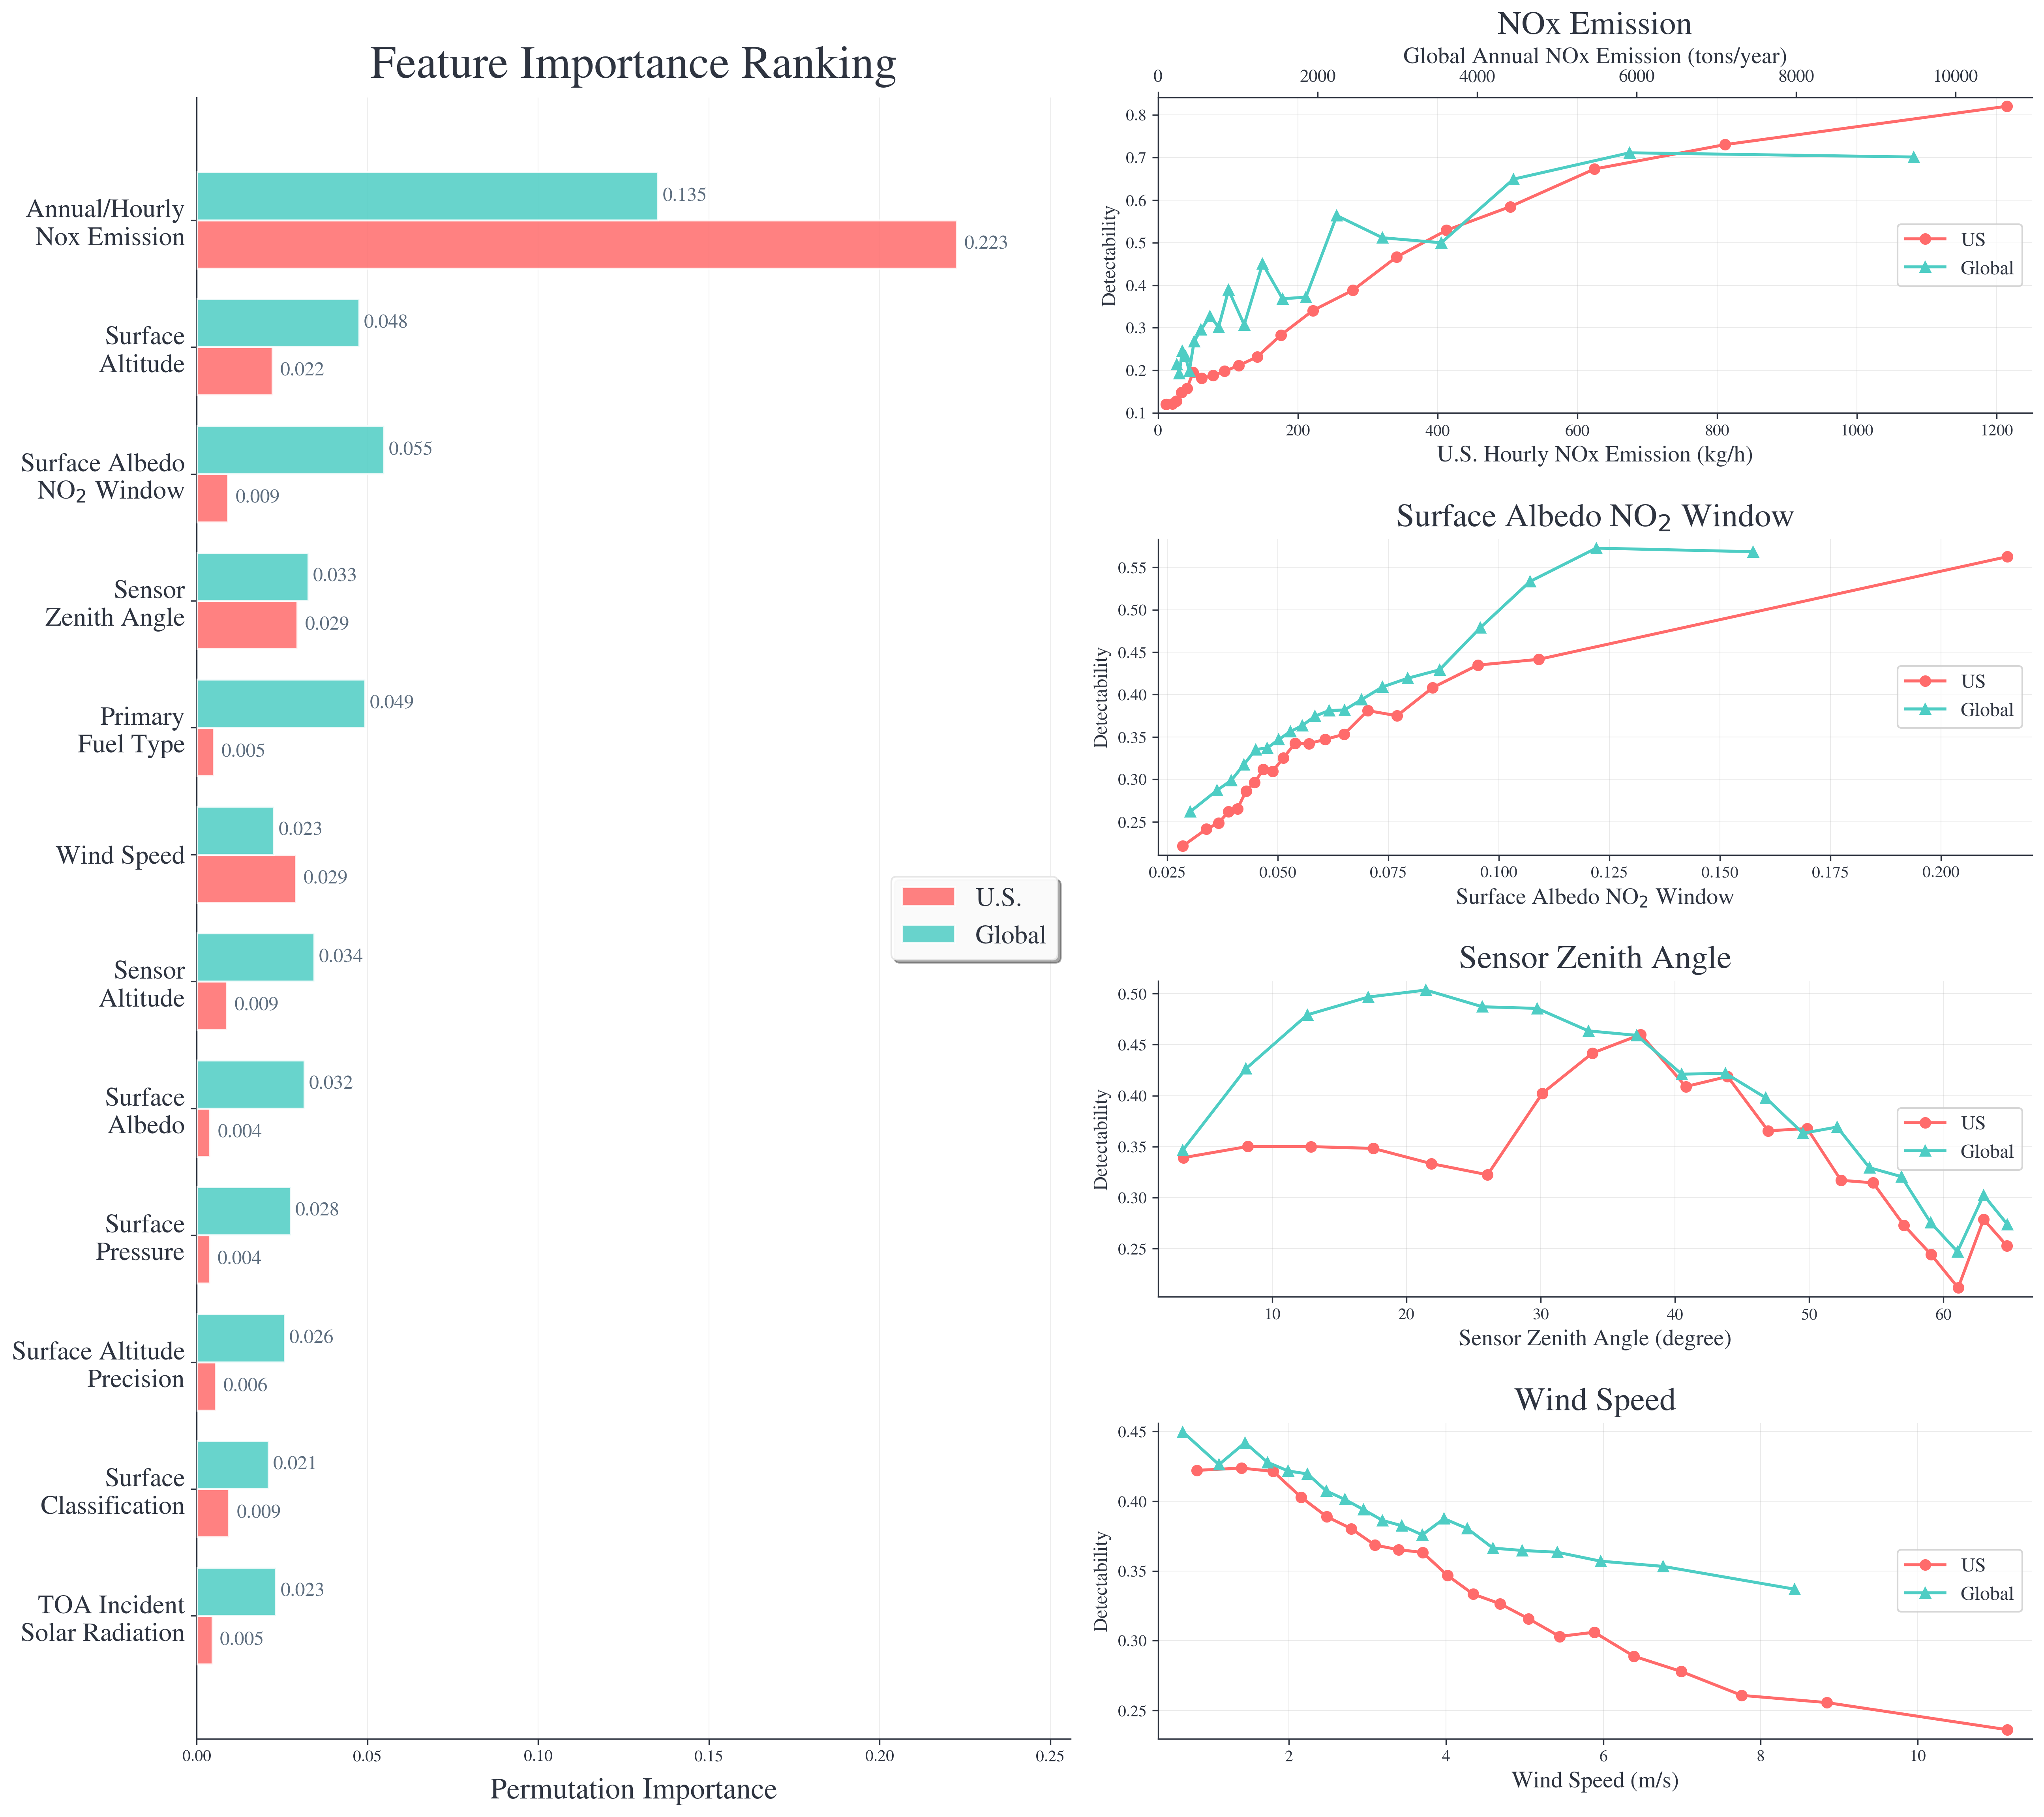

In [7]:
# ─── Combined figure: importance bar (left) + 3 POD curves (right) ───
fig = plt.figure(figsize=(20, 18), facecolor='white')
n = len(top3_feats)
gs = gridspec.GridSpec(n, 2, width_ratios=[1, 1], hspace=0.4, wspace=0.1)

ax_imp = fig.add_subplot(gs[:, 0])
create_importance_plot(ax_imp,
                       ['US_with_nearby', 'Global_with_nearby'],
                       'mean_with_nearby', merged, top_n=12)

for i, feat in enumerate(top3_feats):
    ax_pod = fig.add_subplot(gs[i, 1])
    feat_p = pretty_name(feat)
    try:    us_col = resolve_feature_col(df_us, feat_p)
    except KeyError: us_col = resolve_feature_col(df_us, feat)
    try:    gl_col = resolve_feature_col(df_gl, feat_p)
    except KeyError: gl_col = resolve_feature_col(df_gl, feat)
    plot_overlay_us_global(ax_pod, feat_p, df_us, df_gl, us_col, gl_col, tgt_us, tgt_gl)

out_pdf = os.path.join(OUT_DIR, 'feature_importance_pod_curves.pdf')
out_png = os.path.join(OUT_DIR, 'feature_importance_pod_curves.png')
plt.savefig(out_pdf, dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(out_png, dpi=300, bbox_inches='tight', facecolor='white')
print(f'Saved: {out_pdf}')
print(f'Saved: {out_png}')
plt.show()